In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Load dataset — update path to yours
df = pd.read_csv(r'C:\Users\upadh\Desktop\da_projs\customer_churn\data\WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (7043, 21)

Columns:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


=== DATA TYPES ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

=== MISSING VALUES ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
Pap

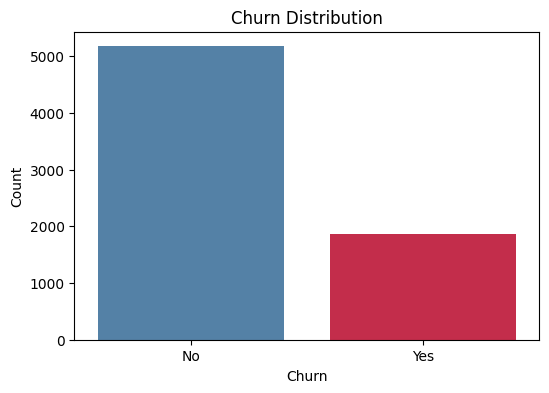

In [3]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== CHURN DISTRIBUTION ===")
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"\nChurn Rate: {churn_counts['Yes'] / len(df) * 100:.2f}%")
print(f"Retention Rate: {churn_counts['No'] / len(df) * 100:.2f}%")

# Visualize
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette=['steelblue', 'crimson'])
plt.title('Churn Distribution')
plt.ylabel('Count')
plt.show()

In [4]:
print("=== COLUMN BREAKDOWN ===")

print("\n--- Customer Demographics ---")
print(df[['gender', 'SeniorCitizen', 'Partner', 'Dependents']].describe())

print("\n--- Services Subscribed ---")
print(df[['PhoneService', 'InternetService', 'OnlineSecurity', 
           'OnlineBackup', 'TechSupport', 'StreamingTV']].nunique())

print("\n--- Account Information ---")
print(df[['Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']].describe())

=== COLUMN BREAKDOWN ===

--- Customer Demographics ---
       SeniorCitizen
count    7043.000000
mean        0.162147
std         0.368612
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000

--- Services Subscribed ---
PhoneService       2
InternetService    3
OnlineSecurity     3
OnlineBackup       3
TechSupport        3
StreamingTV        3
dtype: int64

--- Account Information ---
       MonthlyCharges
count     7043.000000
mean        64.761692
std         30.090047
min         18.250000
25%         35.500000
50%         70.350000
75%         89.850000
max        118.750000


In [5]:
# Check what's inside the problematic rows
print("Rows where TotalCharges is a space:")
print(df[df['TotalCharges'].str.strip() == ''].shape[0], "rows found")

# Fix: convert TotalCharges to numeric, blank spaces become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many NaN values were created
print("\nNaN values in TotalCharges after conversion:", df['TotalCharges'].isnull().sum())

# Fill NaN with MonthlyCharges (these are new customers with 0 tenure)
df['TotalCharges'] = df['TotalCharges'].fillna(df['MonthlyCharges'])

# Verify fix
print("\nTotalCharges dtype now:", df['TotalCharges'].dtype)
print("Any remaining nulls:", df['TotalCharges'].isnull().sum())

Rows where TotalCharges is a space:
11 rows found

NaN values in TotalCharges after conversion: 11

TotalCharges dtype now: float64
Any remaining nulls: 0


In [6]:
# Convert Churn from Yes/No text to 1/0 numbers
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert SeniorCitizen from 0/1 to readable labels
df['SeniorCitizen_Label'] = df['SeniorCitizen'].map({0: 'Non-Senior', 1: 'Senior'})

# Verify
print("Churn_Binary sample:")
print(df[['Churn', 'Churn_Binary']].head(10))
print("\nSeniorCitizen_Label sample:")
print(df[['SeniorCitizen', 'SeniorCitizen_Label']].head(5))

Churn_Binary sample:
  Churn  Churn_Binary
0    No             0
1    No             0
2   Yes             1
3    No             0
4   Yes             1
5   Yes             1
6    No             0
7    No             0
8   Yes             1
9    No             0

SeniorCitizen_Label sample:
   SeniorCitizen SeniorCitizen_Label
0              0          Non-Senior
1              0          Non-Senior
2              0          Non-Senior
3              0          Non-Senior
4              0          Non-Senior


In [7]:
print("=== CLEANED DATASET SUMMARY ===")
print(f"Total customers: {len(df):,}")
print(f"Churned customers: {df['Churn_Binary'].sum():,}")
print(f"Retained customers: {(df['Churn_Binary']==0).sum():,}")
print(f"Churn rate: {df['Churn_Binary'].mean()*100:.2f}%")
print(f"\nAny remaining nulls:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nData types after cleaning:")
print(df[['TotalCharges', 'MonthlyCharges', 'Churn_Binary']].dtypes)

# Save cleaned version
df.to_csv('telco_churn_cleaned.csv', index=False)
print("\nCleaned dataset saved!")

=== CLEANED DATASET SUMMARY ===
Total customers: 7,043
Churned customers: 1,869
Retained customers: 5,174
Churn rate: 26.54%

Any remaining nulls:
Series([], dtype: int64)

Data types after cleaning:
TotalCharges      float64
MonthlyCharges    float64
Churn_Binary        int64
dtype: object

Cleaned dataset saved!


In [8]:
# Load cleaned data into SQLite
conn = sqlite3.connect('churn.db')
df.to_sql('customers', conn, if_exists='replace', index=False)
print("Database ready!")
print("Total rows loaded:", len(df))

Database ready!
Total rows loaded: 7043


In [9]:
query1 = """
SELECT 
    Contract,
    COUNT(*) as total_customers,
    SUM(Churn_Binary) as churned,
    ROUND(100.0 * SUM(Churn_Binary) / COUNT(*), 2) as churn_rate,
    ROUND(AVG(MonthlyCharges), 2) as avg_monthly_charges,
    ROUND(AVG(tenure), 1) as avg_tenure_months
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC
"""

by_contract = pd.read_sql_query(query1, conn)
print("=== CHURN BY CONTRACT TYPE ===")
print(by_contract.to_string(index=False))

=== CHURN BY CONTRACT TYPE ===
      Contract  total_customers  churned  churn_rate  avg_monthly_charges  avg_tenure_months
Month-to-month             3875     1655       42.71                66.40               18.0
      One year             1473      166       11.27                65.05               42.0
      Two year             1695       48        2.83                60.77               56.7


In [10]:
query2 = """
SELECT 
    InternetService,
    COUNT(*) as total_customers,
    SUM(Churn_Binary) as churned,
    ROUND(100.0 * SUM(Churn_Binary) / COUNT(*), 2) as churn_rate,
    ROUND(AVG(MonthlyCharges), 2) as avg_monthly_charges
FROM customers
GROUP BY InternetService
ORDER BY churn_rate DESC
"""

by_internet = pd.read_sql_query(query2, conn)
print("=== CHURN BY INTERNET SERVICE ===")
print(by_internet.to_string(index=False))

=== CHURN BY INTERNET SERVICE ===
InternetService  total_customers  churned  churn_rate  avg_monthly_charges
    Fiber optic             3096     1297       41.89                91.50
            DSL             2421      459       18.96                58.10
             No             1526      113        7.40                21.08


In [11]:
query3 = """
SELECT 
    CASE 
        WHEN tenure <= 12 THEN '0-12 months'
        WHEN tenure <= 24 THEN '13-24 months'
        WHEN tenure <= 48 THEN '25-48 months'
        ELSE '49+ months'
    END as tenure_group,
    COUNT(*) as total_customers,
    SUM(Churn_Binary) as churned,
    ROUND(100.0 * SUM(Churn_Binary) / COUNT(*), 2) as churn_rate,
    ROUND(AVG(MonthlyCharges), 2) as avg_monthly_charges
FROM customers
GROUP BY tenure_group
ORDER BY churn_rate DESC
"""

by_tenure = pd.read_sql_query(query3, conn)
print("=== CHURN BY TENURE GROUP ===")
print(by_tenure.to_string(index=False))

=== CHURN BY TENURE GROUP ===
tenure_group  total_customers  churned  churn_rate  avg_monthly_charges
 0-12 months             2186     1037       47.44                56.10
13-24 months             1024      294       28.71                61.36
25-48 months             1594      325       20.39                65.93
  49+ months             2239      213        9.51                73.95


In [12]:
query4 = """
SELECT 
    PaymentMethod,
    COUNT(*) as total_customers,
    SUM(Churn_Binary) as churned,
    ROUND(100.0 * SUM(Churn_Binary) / COUNT(*), 2) as churn_rate,
    ROUND(AVG(MonthlyCharges), 2) as avg_monthly_charges
FROM customers
GROUP BY PaymentMethod
ORDER BY churn_rate DESC
"""

by_payment = pd.read_sql_query(query4, conn)
print("=== CHURN BY PAYMENT METHOD ===")
print(by_payment.to_string(index=False))

=== CHURN BY PAYMENT METHOD ===
            PaymentMethod  total_customers  churned  churn_rate  avg_monthly_charges
         Electronic check             2365     1071       45.29                76.26
             Mailed check             1612      308       19.11                43.92
Bank transfer (automatic)             1544      258       16.71                67.19
  Credit card (automatic)             1522      232       15.24                66.51


In [13]:
query5 = """
SELECT 
    SeniorCitizen_Label,
    gender,
    COUNT(*) as total_customers,
    SUM(Churn_Binary) as churned,
    ROUND(100.0 * SUM(Churn_Binary) / COUNT(*), 2) as churn_rate,
    ROUND(AVG(MonthlyCharges), 2) as avg_monthly_charges
FROM customers
GROUP BY SeniorCitizen_Label, gender
ORDER BY churn_rate DESC
"""

by_demographics = pd.read_sql_query(query5, conn)
print("=== CHURN BY DEMOGRAPHICS ===")
print(by_demographics.to_string(index=False))

=== CHURN BY DEMOGRAPHICS ===
SeniorCitizen_Label gender  total_customers  churned  churn_rate  avg_monthly_charges
             Senior Female              568      240       42.25                81.11
             Senior   Male              574      236       41.11                78.54
         Non-Senior Female             2920      699       23.94                62.11
         Non-Senior   Male             2981      694       23.28                61.59


In [14]:
# Save all query results for Power BI
by_contract.to_csv('churn_by_contract.csv', index=False)
by_internet.to_csv('churn_by_internet.csv', index=False)
by_tenure.to_csv('churn_by_tenure.csv', index=False)
by_payment.to_csv('churn_by_payment.csv', index=False)
by_demographics.to_csv('churn_by_demographics.csv', index=False)

# Also save the full cleaned dataset for Power BI
df.to_csv('telco_churn_cleaned.csv', index=False)

conn.close()
print("All files saved for Power BI!")
print("\nFiles ready:")
print("  - churn_by_contract.csv")
print("  - churn_by_internet.csv")
print("  - churn_by_tenure.csv")
print("  - churn_by_payment.csv")
print("  - churn_by_demographics.csv")
print("  - telco_churn_cleaned.csv")

All files saved for Power BI!

Files ready:
  - churn_by_contract.csv
  - churn_by_internet.csv
  - churn_by_tenure.csv
  - churn_by_payment.csv
  - churn_by_demographics.csv
  - telco_churn_cleaned.csv


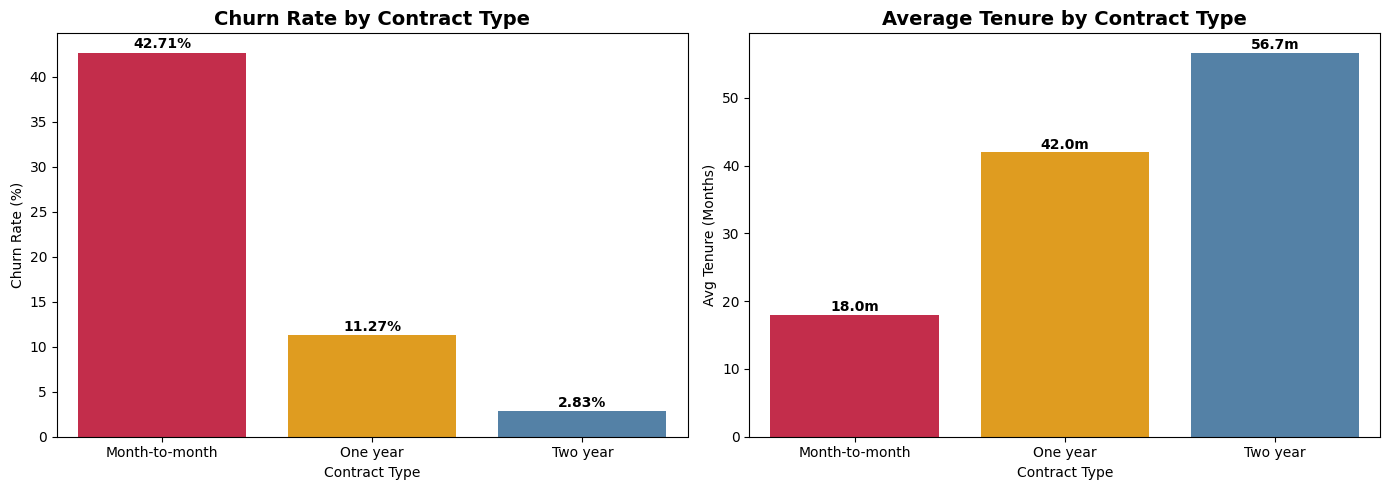

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn rate by contract
sns.barplot(x='Contract', y='churn_rate', data=by_contract, 
            palette=['crimson', 'orange', 'steelblue'], ax=axes[0])
axes[0].set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_xlabel('Contract Type')
for i, v in enumerate(by_contract['churn_rate']):
    axes[0].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

# Average tenure by contract
sns.barplot(x='Contract', y='avg_tenure_months', data=by_contract,
            palette=['crimson', 'orange', 'steelblue'], ax=axes[1])
axes[1].set_title('Average Tenure by Contract Type', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Avg Tenure (Months)')
axes[1].set_xlabel('Contract Type')
for i, v in enumerate(by_contract['avg_tenure_months']):
    axes[1].text(i, v + 0.5, f'{v}m', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

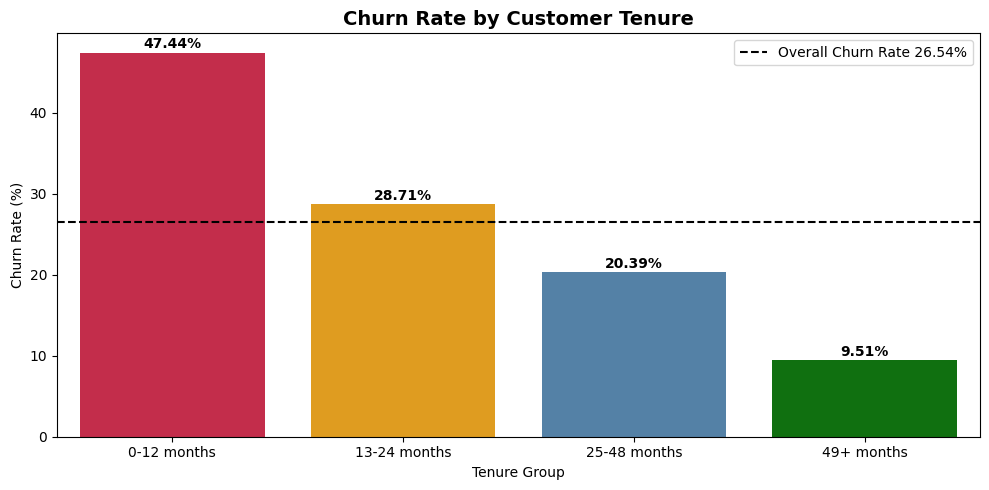

In [16]:
# Sort tenure groups in correct order
tenure_order = ['0-12 months', '13-24 months', '25-48 months', '49+ months']
by_tenure_sorted = by_tenure.set_index('tenure_group').loc[tenure_order].reset_index()

plt.figure(figsize=(10, 5))
bars = sns.barplot(x='tenure_group', y='churn_rate', data=by_tenure_sorted,
                   palette=['crimson', 'orange', 'steelblue', 'green'])
plt.title('Churn Rate by Customer Tenure', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure Group')
for i, v in enumerate(by_tenure_sorted['churn_rate']):
    plt.text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')
plt.axhline(y=26.54, color='black', linestyle='--', label='Overall Churn Rate 26.54%')
plt.legend()
plt.tight_layout()
plt.show()

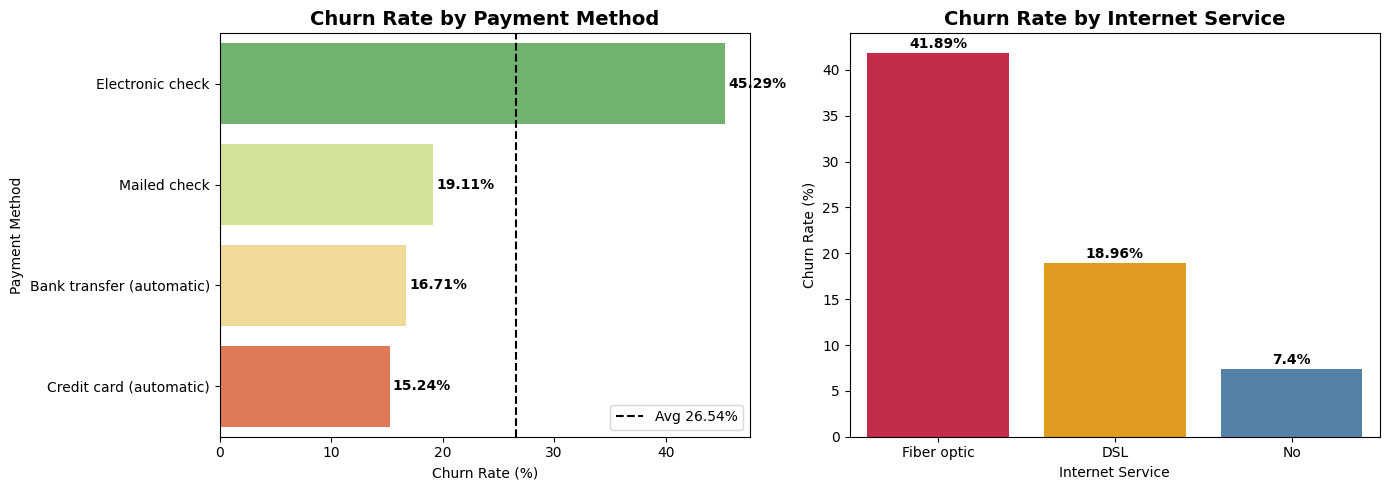

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Payment method
sns.barplot(x='churn_rate', y='PaymentMethod', data=by_payment,
            palette='RdYlGn_r', ax=axes[0])
axes[0].set_title('Churn Rate by Payment Method', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn Rate (%)')
axes[0].set_ylabel('Payment Method')
axes[0].axvline(x=26.54, color='black', linestyle='--', label='Avg 26.54%')
axes[0].legend()
for i, v in enumerate(by_payment['churn_rate']):
    axes[0].text(v + 0.3, i, f'{v}%', va='center', fontweight='bold')

# Internet service
sns.barplot(x='InternetService', y='churn_rate', data=by_internet,
            palette=['crimson', 'orange', 'steelblue'], ax=axes[1])
axes[1].set_title('Churn Rate by Internet Service', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Internet Service')
for i, v in enumerate(by_internet['churn_rate']):
    axes[1].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

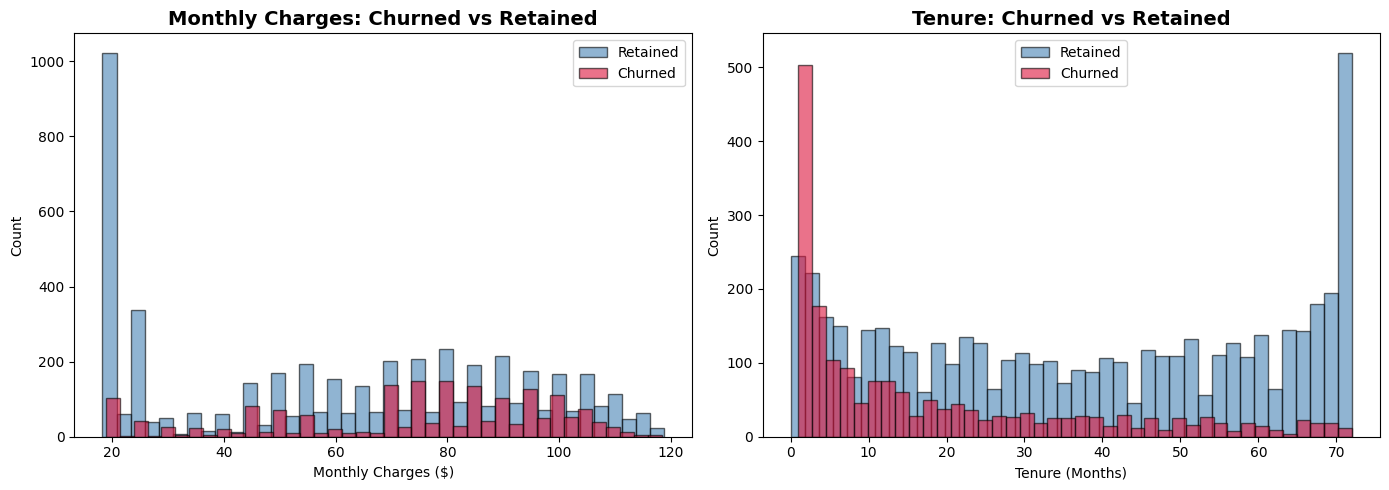

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly charges distribution by churn
axes[0].hist(df[df['Churn']=='No']['MonthlyCharges'], bins=40, 
             alpha=0.6, color='steelblue', label='Retained', edgecolor='black')
axes[0].hist(df[df['Churn']=='Yes']['MonthlyCharges'], bins=40, 
             alpha=0.6, color='crimson', label='Churned', edgecolor='black')
axes[0].set_title('Monthly Charges: Churned vs Retained', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Tenure distribution by churn
axes[1].hist(df[df['Churn']=='No']['tenure'], bins=40,
             alpha=0.6, color='steelblue', label='Retained', edgecolor='black')
axes[1].hist(df[df['Churn']=='Yes']['tenure'], bins=40,
             alpha=0.6, color='crimson', label='Churned', edgecolor='black')
axes[1].set_title('Tenure: Churned vs Retained', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tenure (Months)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()